In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from numfield import CartesianMesh, CartesianField, Fields


# Creation of a 3D Mesh

In [2]:
# 10x10x5 Mesh
dx = np.full(10, 1.0)   # 10 cells along x
dy = np.full(10, 1.0)   # 10 cells along y
dz = np.full(5,  2.0)   # 5  cells along z

mesh = CartesianMesh(dx, dy, dz)

print("Created Mesh:")
print(f"  shape = {mesh.shape}")
print(f"  bounding box = {mesh.bounding_box}")
print(f"  total volume = {mesh.volume}")

Created Mesh:
  shape = (10, 10, 5)
  bounding box = ((0.0, 10.0), (0.0, 10.0), (0.0, 10.0))
  total volume = 1000.0


At instanciation, a CartesianMesh creates (if it can) new attributes for quick access to each axis and delta:
- The names of the axes are given in the axes_names attribute.
- The names of the deltas are the same with a starting "d".
- The attributes are created at runtime and are therefore not known by your IDE

In [3]:
print(mesh.axes_names)
# the attributes are created at runtime and are therefore not known by your IDE
print("x: ", mesh.x) 
print("y: ", mesh.y)
print("dx: ", mesh.dx)

['x', 'y', 'z']
x:  [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
y:  [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
dx:  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


# Creation of scalar field

In [4]:
# Example : density changing linearly with z
Z = mesh.centers[2]   # center z-coordinates of the cells
density_values = 1000 + 10 * Z   # kg/m^3

density_field = CartesianField(
    name="density",
    mesh=mesh,
    values=density_values,
    intensive=True        # density → intensive
)

print("\nDensity Field:")
print(density_field)


Density Field:
intensive CartesianField(density, shape=(10, 10, 5))


# Projection on a coarser Mesh

In [5]:
# New Mesh (5x5x5)
dx2 = np.full(5, 2.0)
dy2 = np.full(5, 2.0)
dz2 = [0.5, 2.5, 4.5, 2., 0.5] # not overlapping mesh on z-axis

coarse_mesh = CartesianMesh(dx2, dy2, dz2)
print("\nCoarse Mesh:")
print(f"  shape = {coarse_mesh.shape}")
print(f"  bounding box = {coarse_mesh.bounding_box}")
print(f"  total volume = {coarse_mesh.volume}")

density_on_coarse = density_field.project_on(coarse_mesh)

print("\nAfter projection:")
print(f"  Original shape: {density_field.shape}")
print(f"  Coarse shape:   {density_on_coarse.shape}")


Coarse Mesh:
  shape = (5, 5, 5)
  bounding box = ((0.0, 10.0), (0.0, 10.0), (0.0, 10.0))
  total volume = 1000.0

After projection:
  Original shape: (10, 10, 5)
  Coarse shape:   (5, 5, 5)


# Add a categorical field
(ex: Name of the material)

In [6]:
# Material field: water below z=5, steel above
material = np.where(Z < 5, "water", "steel")

fields = Fields(mesh)
fields.add_field(density_field)
fields.add_values("material", material)

print("Categorical field 'material':")
print("  Categories:", fields.field_lookup["material"])

Categorical field 'material':
  Categories: ['steel' 'water']


# Sum by category
if the field is intensive, the volume-weighted average is calculated instead of the sum

In [7]:
labels, means = fields.sum_by_category("density", "material")

print("Average densities by material:")
for lbl, val in zip(labels, means):
    print(f"  {lbl}: {val:.2f} kg/m³")

Average densities by material:
  steel: 1070.00 kg/m³
  water: 1020.00 kg/m³


# Slice plotting:

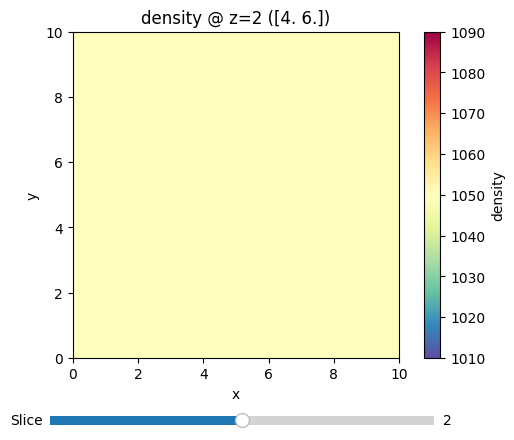

In [8]:
# XY slice at mid-z
fig, ax = density_field.plot(axis=2, dynamic_colorbar=False)

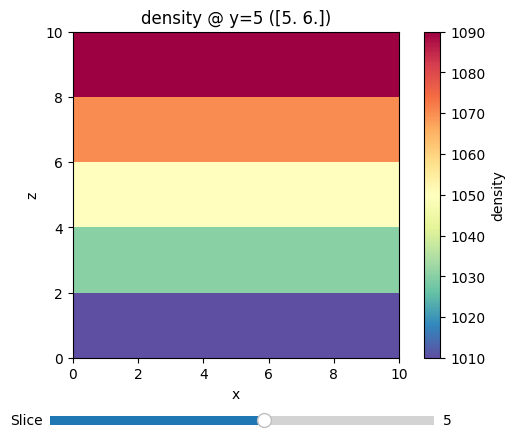

In [9]:
# XZ slice
fig, ax = density_field.plot(axis=1)

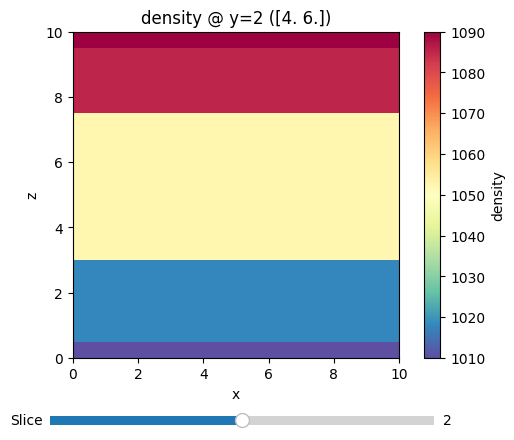

In [10]:
# Coarser mesh, XZ slice
fig, ax = density_on_coarse.plot(axis=1)

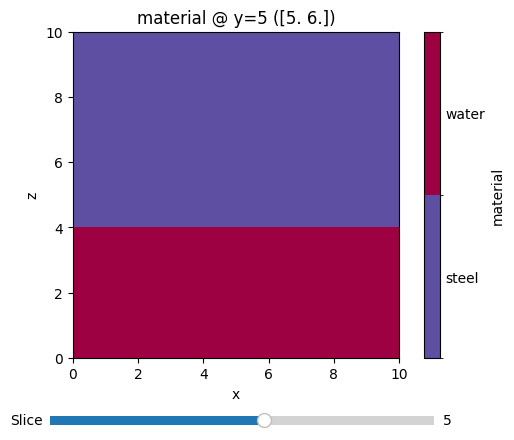

In [11]:
# Material slice
fig, ax = fields.get_field("material").plot(axis=1)

# Other operations:

In [12]:
# Drop the z-dimension → get a 2D mesh
xy_mesh = mesh.drop_dimension(2)

print("Original mesh:\n", mesh)
print("Reduced 2D mesh:\n", xy_mesh)

# Multiply steel densities by 7
mask = fields['material'] == 'steel'
density_field[mask] *= 7                # modifies density in-place

Original mesh:
 CartesianMesh (10, 10, 5):
x0: [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
x1: [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
x2: [ 0.  2.  4.  6.  8. 10.]

Reduced 2D mesh:
 CartesianMesh (10, 10):
x0: [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
x1: [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]



Note that *fields['density']* is **also modified** since fields only contains a reference to *density_field*

In [13]:
# Project a bigger dimension mesh to a smaller one:
mesh3d = mesh.projected_on(xy_mesh)
print(mesh3d)

CartesianMesh (10, 10, 5):
x0: [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
x1: [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
x2: [ 0.  2.  4.  6.  8. 10.]



(<Figure size 640x480 with 2 Axes>, <Axes: xlabel='x', ylabel='y'>)

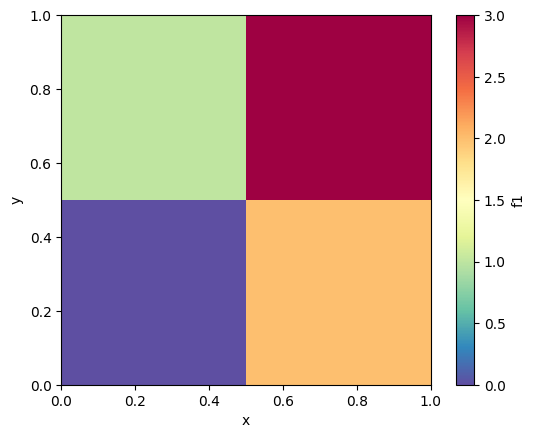

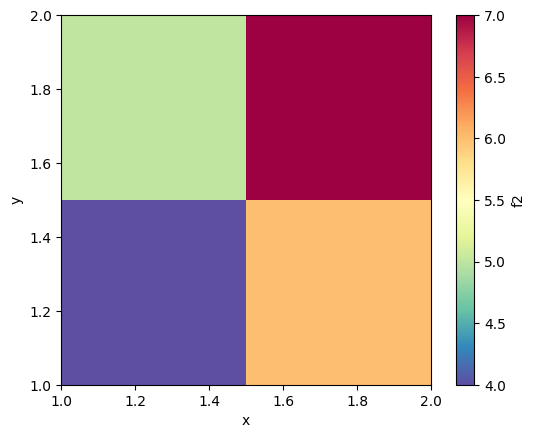

In [ ]:
# merge several fields into one
from numfield import merge_fields, CartesianMesh

dx = np.array([0.5, 0.5])
dy = np.array([0.5, 0.5])

mesh1 = CartesianMesh(dx, dy)   
values = [[0., 1.], [2., 3.]]
f1 = CartesianField('f1', mesh1, values, intensive=True)     

mesh2 = CartesianMesh(dx, dy, origin=(1,1)) # shifting all by 1, the 2 meshes do not overlap
values = [[4., 5.], [6., 7.]]
f2 = CartesianField('f2', mesh2, values, intensive=True)

f1.plot()
f2.plot()

[[0. 1. 0. 0.]
 [2. 3. 0. 0.]
 [0. 0. 4. 5.]
 [0. 0. 6. 7.]]


(<Figure size 640x480 with 2 Axes>, <Axes: xlabel='x', ylabel='y'>)

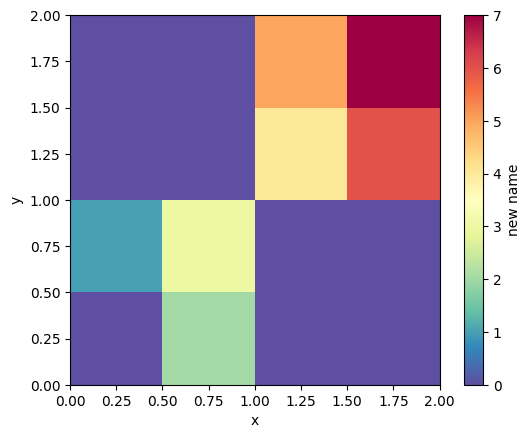

In [15]:
combined_field = merge_fields("new name", f1, f2)
print(combined_field.values)
combined_field.plot()